In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df = df[['Weight', 'Height']]
df.head()

,Weight,Height
0,241.893563,73.847017
1,162.310473,68.781904
2,212.740856,74.110105
3,220.042470,71.730978
4,206.349801,69.881796


In [4]:
df.shape

(10000, 2)

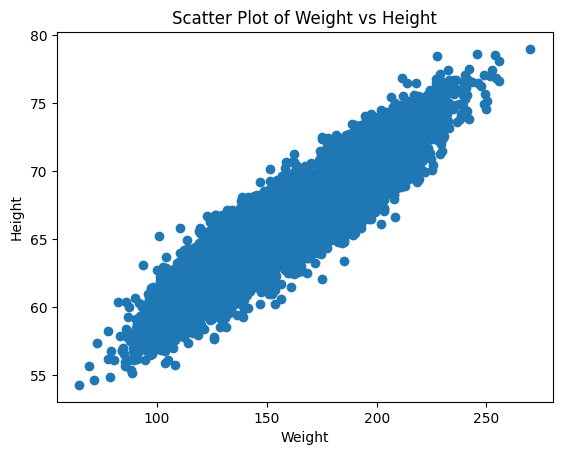

In [5]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Scatter Plot of Weight vs Height')
plt.show()

In [6]:
df.corr()

,Weight,Height
Weight,1.000000,0.924756
Height,0.924756,1.000000


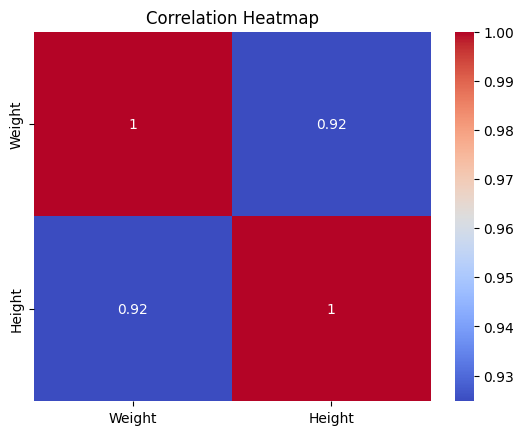

In [7]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
X = df[['Weight']]
y = df['Height']

In [29]:
X

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801
...,...
9995,136.777454
9996,170.867906
9997,128.475319
9998,163.852461


In [30]:
y

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

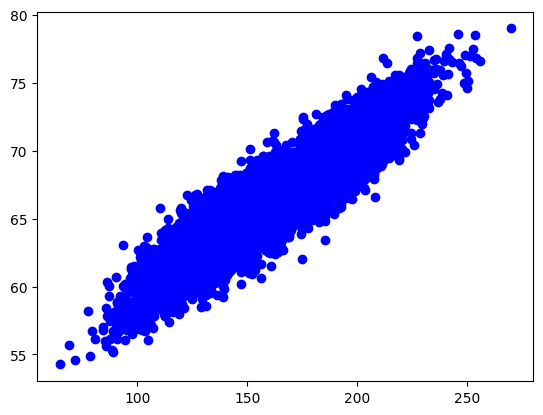

In [32]:
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.show()

In [33]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

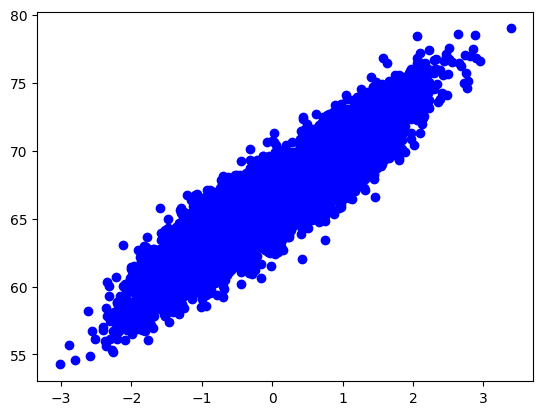

In [34]:
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.show()

In [35]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [36]:
regressor

LinearRegression()

In [37]:
type(X_train)

numpy.ndarray

In [38]:
X_train.shape

(8000, 1)

In [39]:
np.array(X_train).shape

(8000, 1)

In [40]:
X_train = np.array(X_train).reshape(-1, 1)
X_test = np.array(X_test).reshape(-1, 1)

In [41]:
regressor.fit(X_train, y_train)

LinearRegression()

In [42]:
print('Coefficients:', regressor.coef_)
print('Intercept:', regressor.intercept_)

Coefficients: [3.55479288]
Intercept: 66.3596814074891


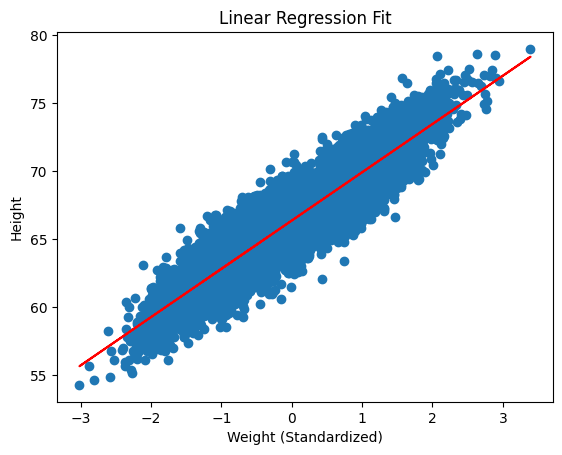

In [27]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), color='red')
plt.xlabel('Weight (Standardized)')
plt.ylabel('Height')
plt.title('Linear Regression Fit')
plt.show()

In [43]:
y_pred_test = regressor.predict(X_test)
y_pred_test

array([67.66759668, 70.11347651, 67.34604311, ..., 62.34937415,
       69.27157847, 59.829821  ])

In [44]:
y_test

6252    68.687232
4684    68.829334
1731    66.398128
4742    71.929340
4521    67.042903
          ...    
6412    65.748601
8285    60.731857
7853    62.188933
1095    67.068304
6929    58.632720
Name: Height, Length: 2000, dtype: float64

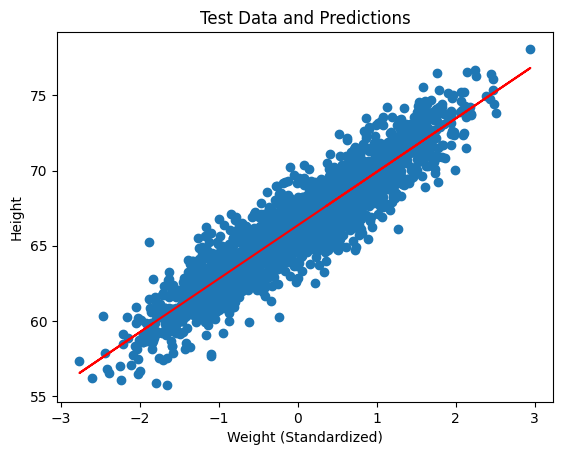

In [45]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_test, color='red')
plt.xlabel('Weight (Standardized)')
plt.ylabel('Height')
plt.title('Test Data and Predictions')
plt.show()

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)
print('Root Mean Squared Error:', rmse)

Mean Squared Error: 2.112361948474147
Mean Absolute Error: 1.1588656330992098
Root Mean Squared Error: 1.4533966934303062


In [48]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_test)
print('R-squared:', r2)

R-squared: 0.8578120230894554


In [49]:
1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

0.8577408579358465

In [50]:
regressor.predict(scaler.transform([[150]]))

c:\Users\N I T R O V15\.conda\envs\ga\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([65.10305385])

In [51]:
residuals = y_test - y_pred_test
residuals

6252    1.019636
4684   -1.284143
1731   -0.947915
4742   -0.390533
4521   -1.690374
          ...   
6412    1.525611
8285   -1.039337
7853   -0.160441
1095   -2.203274
6929   -1.197101
Name: Height, Length: 2000, dtype: float64

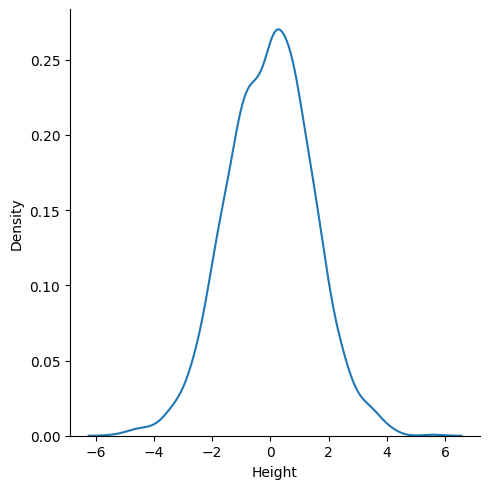

In [53]:
import seaborn as sns
sns.displot(residuals, kind='kde')

In [54]:
import joblib
joblib.dump(regressor, 'linear_regressor.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [55]:
regressor_loaded = joblib.load('linear_regressor.pkl')
scaler_loaded = joblib.load('scaler.pkl')

In [56]:
regressor_loaded.predict(scaler_loaded.transform([[150]]))

c:\Users\N I T R O V15\.conda\envs\ga\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([65.10305385])